# Streaming & Batch Crossmatch with HATS Catalogs

**HATS** (Hierarchical Adaptive Tiling Scheme) is a cloud-native format for astronomical catalogs, partitioned by HEALPix pixels for efficient spatial queries. **Crossmatching** finds objects that appear in two different catalogs by matching sky positions within a given radius.

This notebook demonstrates two ways to crossmatch HATS catalogs:

- **Batch** — load both catalogs, build a lazy Dask execution plan, then `.compute()` the full result at once. Best for analytics over the complete match set.
- **Streaming** — iterate over crossmatch results row-by-row as they become available. Best for incremental processing, ML pipelines, or memory-constrained environments.

We'll crossmatch **Galaxy Zoo 10** (`gz10`, ~60k objects) against **SDSS** (`sdss`, ~4M objects) using a 1° cone search to keep runtime short.

In [1]:
import sys
import time
import warnings

import lsdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", message="The behavior of array concatenation with empty entries")

# Catalog URLs
URL_A = "hf://datasets/UniverseTBD/mmu_gz10"       # Galaxy Zoo 10 (medium)
URL_B = "hf://datasets/UniverseTBD/mmu_sdss_sdss"   # SDSS (large)

# Cone search filter — COSMOS/SDSS field center, 1° radius
CONE_RA = 150.0
CONE_DEC = 2.0
CONE_RADIUS_ARCSEC = 1.0 * 3600  # 1 degree in arcseconds
RADIUS_ARCSEC = 1.0              # crossmatch radius

region = lsdb.ConeSearch(CONE_RA, CONE_DEC, CONE_RADIUS_ARCSEC)
print(f"Cone search: RA={CONE_RA}°, Dec={CONE_DEC}°, radius=1°")
print(f"Crossmatch radius: {RADIUS_ARCSEC} arcsec")

Cone search: RA=150.0°, Dec=2.0°, radius=1°
Crossmatch radius: 1.0 arcsec


In [2]:
# --- Batch crossmatch ---

# Phase 1: Load catalogs
t0 = time.perf_counter()
cat_a = lsdb.open_catalog(URL_A, search_filter=region)
cat_b = lsdb.open_catalog(URL_B, search_filter=region)
time_load = time.perf_counter() - t0
print(f"Loaded catalogs in {time_load:.2f}s")
print(f"  cat_a partitions: {len(cat_a.get_healpix_pixels())}, cat_b partitions: {len(cat_b.get_healpix_pixels())}")

# Phase 2: Plan crossmatch (lazy)
t0 = time.perf_counter()
xmatch = cat_a.crossmatch(
    cat_b,
    n_neighbors=1,
    radius_arcsec=RADIUS_ARCSEC,
    suffixes=("_a", "_b"),
    suffix_method="all_columns",
)
time_plan = time.perf_counter() - t0
print(f"Planned crossmatch in {time_plan:.2f}s (lazy — no data moved yet)")

# Phase 3: Compute
t0 = time.perf_counter()
batch_result = xmatch.compute()
time_compute = time.perf_counter() - t0
batch_total_time = time_load + time_plan + time_compute

print(f"Computed in {time_compute:.2f}s")
print(f"\n--- Batch summary ---")
print(f"  Total matches: {len(batch_result):,}")
print(f"  Load / Plan / Compute: {time_load:.2f}s / {time_plan:.2f}s / {time_compute:.2f}s")
print(f"  Total time: {batch_total_time:.2f}s")

Loaded catalogs in 7.35s
  cat_a partitions: 3, cat_b partitions: 3
Planned crossmatch in 3.14s (lazy — no data moved yet)


Computing Catalog:   0%|          | 0/22 [00:00<?, ?it/s]

Computed in 4.89s

--- Batch summary ---
  Total matches: 8
  Load / Plan / Compute: 7.35s / 3.14s / 4.89s
  Total time: 15.37s


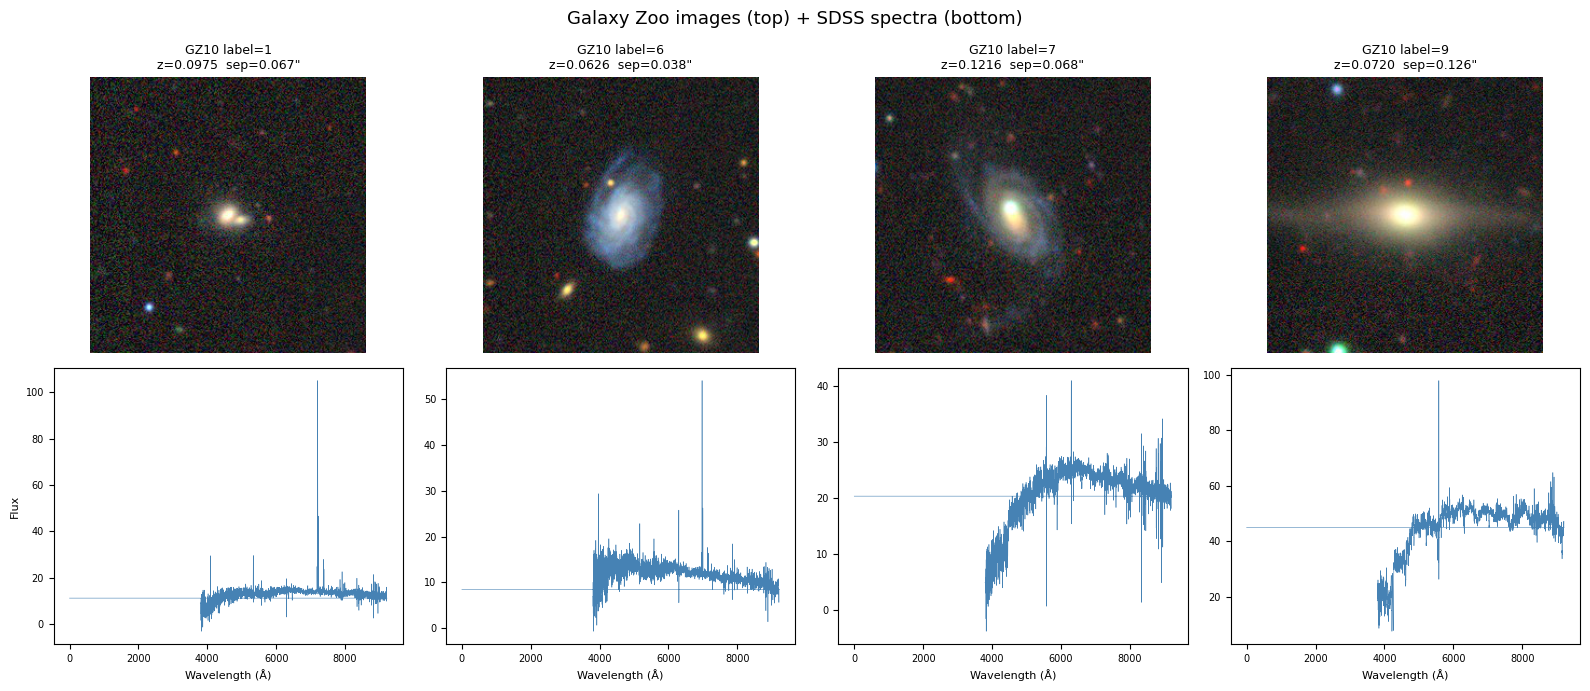

In [8]:
# --- Display Galaxy Zoo images + SDSS spectra ---

from io import BytesIO
from PIL import Image

# Filter to rows that have both image and spectrum data
has_image = batch_result["rgb_image_a"].apply(lambda x: x is not None and len(x.get("bytes", b"")) > 0)
has_spectrum = batch_result["spectrum_b"].apply(lambda x: x is not None and len(x) > 0)
show_rows = batch_result[has_image & has_spectrum]

n_show = min(len(show_rows), 4)
if n_show > 0:
    fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 7),
                             gridspec_kw={"height_ratios": [1, 1]})
    if n_show == 1:
        axes = axes.reshape(2, 1)

    for col, (_, row) in enumerate(show_rows.head(n_show).iterrows()):
        # Top row: galaxy image
        ax_img = axes[0, col]
        img = Image.open(BytesIO(row["rgb_image_a"]["bytes"]))
        ax_img.imshow(img)
        label = row.get("gz10_label_a", "")
        dist = row.get("_dist_arcsec", float("nan"))
        z = row.get("redshift_a", float("nan"))
        ax_img.set_title(f"GZ10 label={label}\nz={z:.4f}  sep={dist:.3f}\"", fontsize=9)
        ax_img.axis("off")

        # Bottom row: SDSS spectrum
        ax_spec = axes[1, col]
        spec = row["spectrum_b"]
        wavelengths = spec["lambda"]
        fluxes = spec["flux"]
        ax_spec.plot(wavelengths, fluxes, linewidth=0.4, color="steelblue")
        ax_spec.set_xlabel("Wavelength (Å)", fontsize=8)
        if col == 0:
            ax_spec.set_ylabel("Flux", fontsize=8)
        ax_spec.tick_params(labelsize=7)

    fig.suptitle("Galaxy Zoo images (top) + SDSS spectra (bottom)", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No rows with both image and spectrum data found.")

In [15]:
# --- Streaming crossmatch ---

sys.path.insert(0, "../reference")
from hats_crossmatch import ThroughputCounter, stream_crossmatch

t0 = time.perf_counter()
ds = stream_crossmatch(
    URL_A,
    URL_B,
    radius_arcsec=RADIUS_ARCSEC,
    n_neighbors=1,
    suffixes=("_a", "_b"),
    search_filter=region,
)

counter = ThroughputCounter(ds)
streamed_rows = []
for row in counter:
    streamed_rows.append(row)

stream_total_time = time.perf_counter() - t0

print(f"--- Streaming summary ---")
print(counter.summary())
print(f"\nCollected {len(streamed_rows):,} rows")

--- Streaming summary ---
  Matched rows:    8
  Time to first:   7.374s
  Total time:      7.38s
  Throughput:      1 matched/s, ~0 scanned/s

Collected 8 rows


In [18]:
# --- Compare streaming vs batch ---

stream_df = pd.DataFrame(streamed_rows)

comparison = pd.DataFrame({
    "Metric": ["Total time (s)", "Rows returned", "Time to first row (s)"],
    "Batch": [
        f"{batch_total_time:.2f}",
        f"{len(batch_result):,}",
        f"{batch_total_time:.2f}",
    ],
    "Streaming": [
        f"{stream_total_time:.2f}",
        f"{len(streamed_rows):,}",
        f"{counter.time_to_first:.3f}" if counter.time_to_first else "N/A",
    ],
})

print("Batch returns the complete result set after all computation finishes.")
print("Streaming yields rows incrementally — useful when you need fast time-to-first-row")
print("or want to process results without waiting for the full crossmatch.\n")
print(comparison.to_string(index=False))

Batch returns the complete result set after all computation finishes.
Streaming yields rows incrementally — useful when you need fast time-to-first-row
or want to process results without waiting for the full crossmatch.

               Metric Batch Streaming
       Total time (s) 15.37     14.62
        Rows returned     8         8
Time to first row (s) 15.37     7.374
